In [2]:
import pandas as pd

# Data Loading and Exploration

# 1. loading data
file_path = 'data/transaction_dataset.csv' 
df = pd.read_csv(file_path)
print("loading success!")

# 2. File Info
print(f"\nFile Info (rows, columns): {df.shape}")

# 3. Count Flags
# '1' means fraud, '0' means normal
if 'FLAG' in df.columns:
    print("\n----- Flag Distribution -----")
    print(df['FLAG'].value_counts())
    
    print("\n----- Fraud Ratio -----")
    print(df['FLAG'].value_counts(normalize=True) * 100) 
else:
    print("\nUnable to find 'FLAG' columns, please check the dataset.")

loading success!

File Info (rows, columns): (9841, 51)

----- Flag Distribution -----
FLAG
0    7662
1    2179
Name: count, dtype: int64

----- Fraud Ratio -----
FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [3]:
# Data Cleaning

# 1. Drop irrelevant identifiers 
# Address and Index don't help in finding general fraud patterns
to_drop = ['Index', 'Address', 'Unnamed: 0']
df_cleaned = df.drop(columns=[c for c in to_drop if c in df.columns])

# 2. Drop constant columns (columns with only 1 unique value)
constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() <= 1]
df_cleaned = df_cleaned.drop(columns=constant_cols)

# 3. Coerce Features to Numeric
for col in df_cleaned.columns:
    if col != 'FLAG':  # Protect our target variable from being altered
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# 4. Handle Missing Values
# Using Median is robust against outliers in financial data
df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))

print(f"Data cleaned! Remaining features: {df_cleaned.shape[1]}")


Data cleaned! Remaining features: 41


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Feature-Target Split
X = df_cleaned.drop('FLAG', axis=1)
y = df_cleaned['FLAG']

# 2. Train-Test Split (80/20 ratio)
# We use 'stratify=y' to maintain the 22% fraud ratio in both sets before resampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Feature Scaling (Essential for distance-based algorithms like KNN and SMOTE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Apply SMOTE to the TRAINING set
# This creates synthetic fraud cases to match the number of normal cases
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("--- Data Distribution After SMOTE ---")
print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE:  {Counter(y_train_res)}")

--- Data Distribution After SMOTE ---
Before SMOTE: Counter({0: 6129, 1: 1743})
After SMOTE:  Counter({0: 6129, 1: 6129})


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. TrainingKNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res, y_train_res)

# 2. Score
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1533
           1       0.81      0.91      0.86       436

    accuracy                           0.93      1969
   macro avg       0.89      0.93      0.91      1969
weighted avg       0.94      0.93      0.94      1969



--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1533
           1       0.96      0.93      0.95       436

    accuracy                           0.98      1969
   macro avg       0.97      0.96      0.97      1969
weighted avg       0.98      0.98      0.98      1969



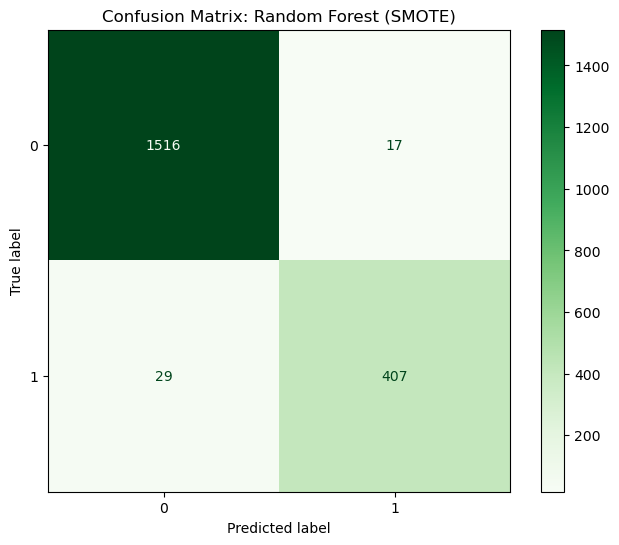

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Initialize Random Forest
# n_estimators=100 means we are building a "forest" of 100 Decision Trees
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model on the SMOTE-balanced data
rf.fit(X_train_res, y_train_res)

# 3. Predict on the unseen 20% test set
y_pred_rf = rf.predict(X_test_scaled)

# 4. Final Evaluation
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# 5. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax, cmap='Greens')
plt.title('Confusion Matrix: Random Forest (SMOTE)')
plt.show()

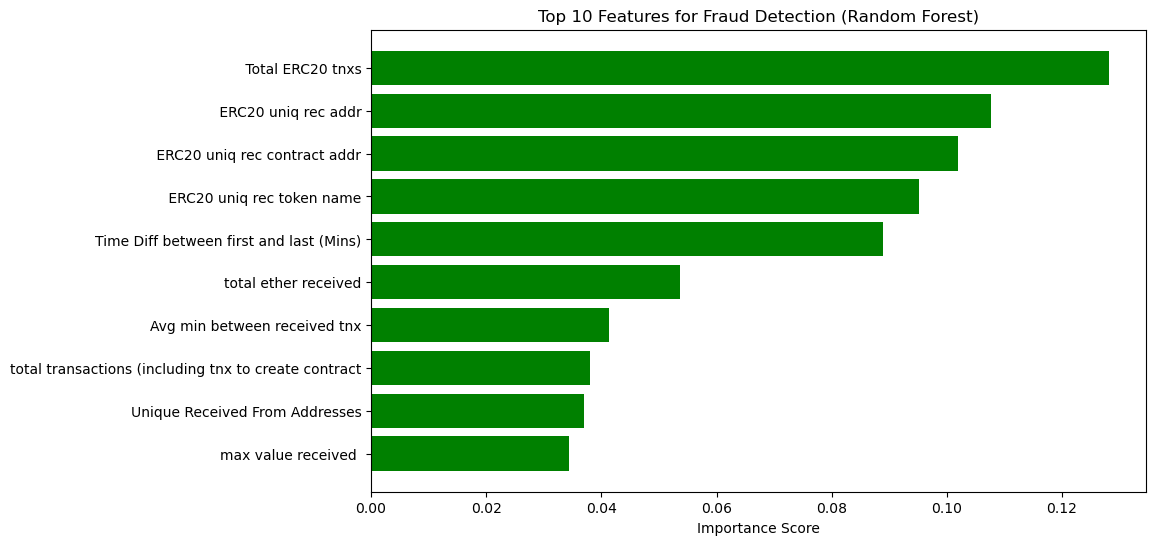

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance scores
importances = rf.feature_importances_
feature_names = X.columns

# Build a DataFrame and sort by importance
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Top 10 features visualization
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10), color='green')
plt.gca().invert_yaxis()
plt.title('Top 10 Features for Fraud Detection (Random Forest)')
plt.xlabel('Importance Score')
plt.show()